<a href="https://colab.research.google.com/github/NikhilGeorge01/ML-Prac/blob/main/MLAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# a) importing and loading dataset
from sklearn.datasets import fetch_openml
data = fetch_openml(name="parkinsons", version=1, as_frame=True)
X = data.data
y = data.target.astype(int)

In [3]:
# b) splitting of data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c) objectives of logistic regression with l2 regularization:


L2 Algorithm is Used to penalize large weights by adding a penalty to the mean squared error, for logistic regression log loss is reduced by penalizing mean square error after assigning weights, and so decision boundaries are kept smooth

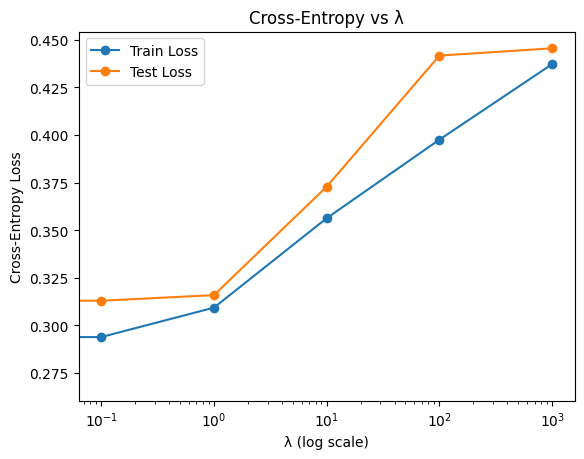

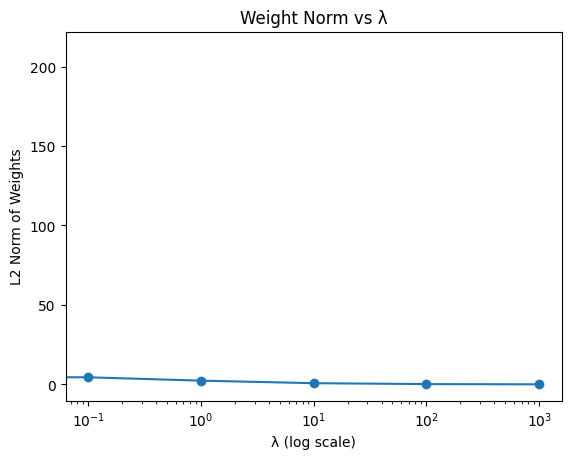

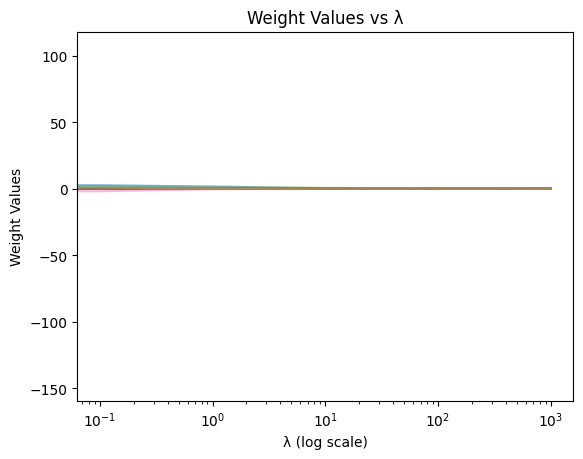

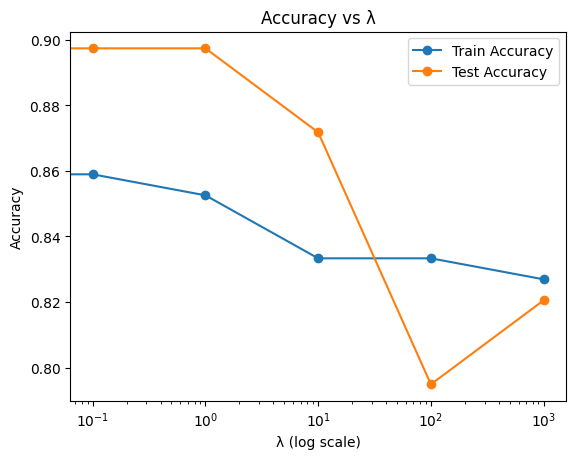

In [6]:
#d)
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score

lambdas = [0, 0.1, 1, 10, 100, 1000]
train_losses, test_losses = [], []
l2_norms, accuracies_train, accuracies_test = [], [], []
weights_list = []
for l in lambdas:
    if l == 0:
        model = LogisticRegression(
            penalty=None, solver="lbfgs", max_iter=10000
        )
    else:
        model = LogisticRegression(
            penalty="l2", C=1/l, solver="lbfgs", max_iter=10000
        )

    model.fit(X_train, y_train)

    y_train_prob = model.predict_proba(X_train)[:, 1]
    y_test_prob = model.predict_proba(X_test)[:, 1]

    train_losses.append(log_loss(y_train, y_train_prob))
    test_losses.append(log_loss(y_test, y_test_prob))

    w = model.coef_.flatten()
    weights_list.append(w)
    l2_norms.append(np.linalg.norm(w, 2))

    accuracies_train.append(accuracy_score(y_train, model.predict(X_train)))
    accuracies_test.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(lambdas, train_losses, marker='o', label="Train Loss")
plt.plot(lambdas, test_losses, marker='o', label="Test Loss")
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs λ")
plt.legend()
plt.show()

plt.plot(lambdas, l2_norms, marker='o')
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("L2 Norm of Weights")
plt.title("Weight Norm vs λ")
plt.show()
weights_array = np.array(weights_list)

for i in range(weights_array.shape[1]):
    plt.plot(lambdas, weights_array[:, i], alpha=0.5)
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Weight Values")
plt.title("Weight Values vs λ")
plt.show()

plt.plot(lambdas, accuracies_train, marker='o', label="Train Accuracy")
plt.plot(lambdas, accuracies_test, marker='o', label="Test Accuracy")
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs λ")
plt.legend()
plt.show()

In [7]:
#e)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

def gaussian_basis_functions(x, means, sigma):
    return np.exp(-((x - means)**2) / (2 * sigma**2))

sigmas = [0.1, 0.5, 1, 5, 10]
X_train_transformed = {}
X_test_transformed = {}

for sigma in sigmas:
    transformed_features_train = []
    transformed_features_test = []
    for col in X_train.columns:
        means = np.linspace(-10, 10, 5)
        transformed_train = gaussian_basis_functions(X_train[col].values[:, np.newaxis], means, sigma)
        transformed_test = gaussian_basis_functions(X_test[col].values[:, np.newaxis], means, sigma)
        transformed_features_train.append(transformed_train)
        transformed_features_test.append(transformed_test)

    X_train_transformed[sigma] = np.hstack(transformed_features_train)
    X_test_transformed[sigma] = np.hstack(transformed_features_test)

    # Add bias term (column of ones)
    X_train_transformed[sigma] = np.hstack([np.ones((X_train_transformed[sigma].shape[0], 1)), X_train_transformed[sigma]])
    X_test_transformed[sigma] = np.hstack([np.ones((X_test_transformed[sigma].shape[0], 1)), X_test_transformed[sigma]])

    print(f"Shape of transformed training data for sigma={sigma}: {X_train_transformed[sigma].shape}")
    print(f"Shape of transformed testing data for sigma={sigma}: {X_test_transformed[sigma].shape}")

Shape of transformed training data for sigma=0.1: (156, 111)
Shape of transformed testing data for sigma=0.1: (39, 111)
Shape of transformed training data for sigma=0.5: (156, 111)
Shape of transformed testing data for sigma=0.5: (39, 111)
Shape of transformed training data for sigma=1: (156, 111)
Shape of transformed testing data for sigma=1: (39, 111)
Shape of transformed training data for sigma=5: (156, 111)
Shape of transformed testing data for sigma=5: (39, 111)
Shape of transformed training data for sigma=10: (156, 111)
Shape of transformed testing data for sigma=10: (39, 111)


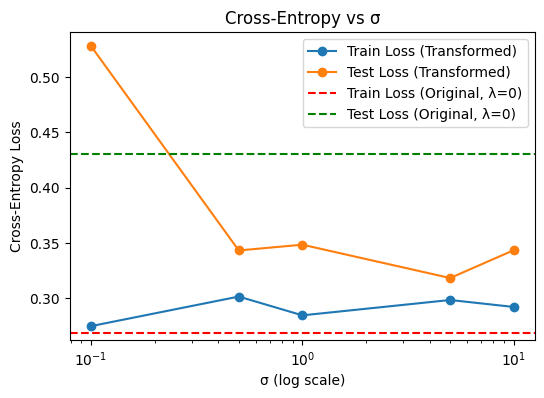

In [8]:
train_losses_transformed, test_losses_transformed = [], []

for sigma in sigmas:
    model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    model.fit(X_train_transformed[sigma], y_train)

    y_train_prob_transformed = model.predict_proba(X_train_transformed[sigma])[:, 1]
    y_test_prob_transformed = model.predict_proba(X_test_transformed[sigma])[:, 1]

    train_losses_transformed.append(log_loss(y_train, y_train_prob_transformed))
    test_losses_transformed.append(log_loss(y_test, y_test_prob_transformed))

plt.figure(figsize=(6,4))
plt.plot(sigmas, train_losses_transformed, marker='o', label="Train Loss (Transformed)")
plt.plot(sigmas, test_losses_transformed, marker='o', label="Test Loss (Transformed)")
plt.axhline(y=train_losses[0], color='r', linestyle='--', label="Train Loss (Original, λ=0)")
plt.axhline(y=test_losses[0], color='g', linestyle='--', label="Test Loss (Original, λ=0)")
plt.xscale("log")
plt.xlabel("σ (log scale)")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs σ")
plt.legend()
plt.show()

Smaller values of σ lead to more localized basis functions, increasing model complexity and potentially causing overfitting (low training error, high test error). Larger values of σ lead to smoother basis functions, reducing complexity and potentially increasing bias (high training error, high test error), demonstrating the bias-variance trade-off.

In [9]:
X_train_concat = []
X_test_concat = []

for sigma in sigmas:
    X_train_concat.append(X_train_transformed[sigma])
    X_test_concat.append(X_test_transformed[sigma])

X_train_combined = np.hstack(X_train_concat)
X_test_combined = np.hstack(X_test_concat)

print(f"Shape of combined transformed training data: {X_train_combined.shape}")
print(f"Shape of combined transformed testing data: {X_test_combined.shape}")

Shape of combined transformed training data: (156, 555)
Shape of combined transformed testing data: (39, 555)


In [10]:
lambdas_transformed = [0, 0.1, 1, 10, 100, 1000, 10000]
train_losses_transformed_reg = []
test_losses_transformed_reg = []
l2_norms_transformed_reg = []

for l in lambdas_transformed:
    if l == 0:
        model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    else:
        model = LogisticRegression(penalty="l2", C=1/l, solver="lbfgs", max_iter=10000)

    model.fit(X_train_combined, y_train)

    y_train_prob_transformed_reg = model.predict_proba(X_train_combined)[:, 1]
    y_test_prob_transformed_reg = model.predict_proba(X_test_combined)[:, 1]

    train_losses_transformed_reg.append(log_loss(y_train, y_train_prob_transformed_reg))
    test_losses_transformed_reg.append(log_loss(y_test, y_test_prob_transformed_reg))

    w_transformed_reg = model.coef_.flatten()
    l2_norms_transformed_reg.append(np.linalg.norm(w_transformed_reg, 2))

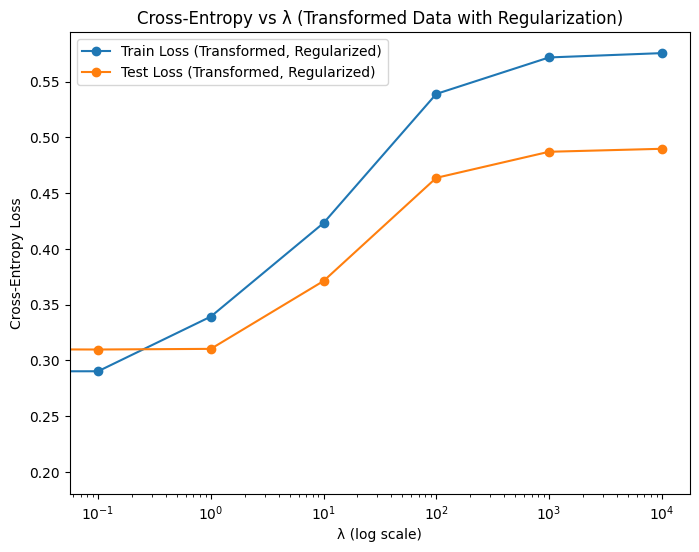

In [11]:
plt.figure(figsize=(8, 6))
plt.plot(lambdas_transformed, train_losses_transformed_reg, marker='o', label="Train Loss (Transformed, Regularized)")
plt.plot(lambdas_transformed, test_losses_transformed_reg, marker='o', label="Test Loss (Transformed, Regularized)")
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("Cross-Entropy Loss")
plt.title("Cross-Entropy vs λ (Transformed Data with Regularization)")
plt.legend()
plt.show()

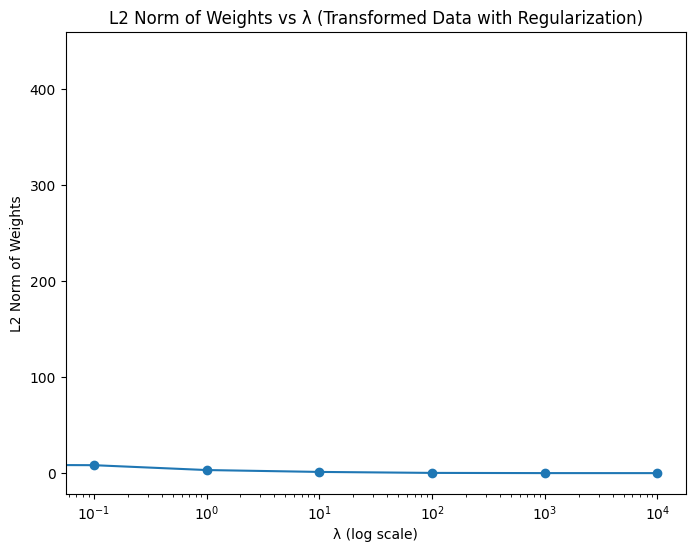

In [12]:
plt.figure(figsize=(8, 6))
plt.plot(lambdas_transformed, l2_norms_transformed_reg, marker='o')
plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("L2 Norm of Weights")
plt.title("L2 Norm of Weights vs λ (Transformed Data with Regularization)")
plt.show()

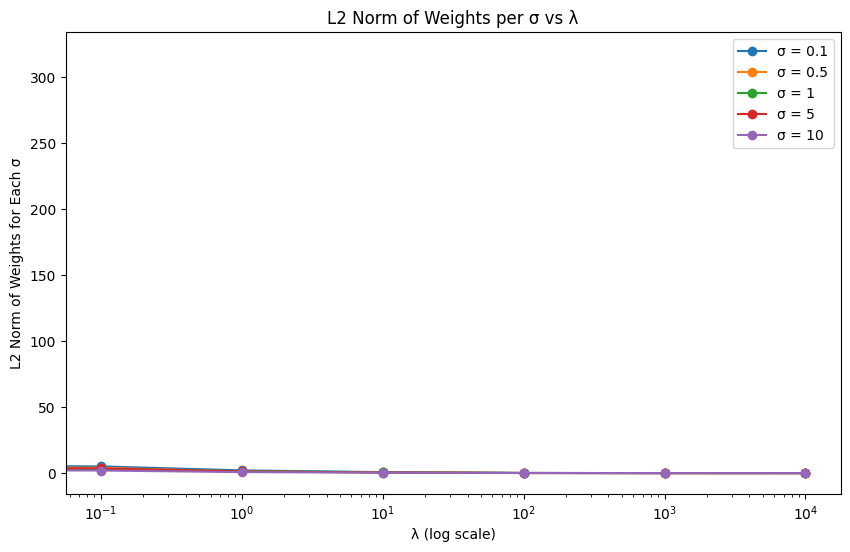

In [13]:
l2_norms_per_sigma = {sigma: [] for sigma in sigmas}

for l in lambdas_transformed:
    if l == 0:
        model = LogisticRegression(penalty=None, solver="lbfgs", max_iter=10000)
    else:
        model = LogisticRegression(penalty="l2", C=1/l, solver="lbfgs", max_iter=10000)

    model.fit(X_train_combined, y_train)

    # Calculate slice indices for each sigma
    feature_start_index = 0
    for i, sigma in enumerate(sigmas):
        num_features_per_sigma = 1 + 5 * X_train.shape[1] # 1 for bias, 5 for basis functions per original feature
        feature_end_index = feature_start_index + num_features_per_sigma

        # Extract weights for the current sigma (excluding bias)
        weights_sigma = model.coef_.flatten()[feature_start_index + 1 : feature_end_index]

        # Calculate L2 norm and store
        l2_norms_per_sigma[sigma].append(np.linalg.norm(weights_sigma, 2))

        feature_start_index = feature_end_index

plt.figure(figsize=(10, 6))
for sigma in sigmas:
    plt.plot(lambdas_transformed, l2_norms_per_sigma[sigma], marker='o', label=f'σ = {sigma}')

plt.xscale("log")
plt.xlabel("λ (log scale)")
plt.ylabel("L2 Norm of Weights for Each σ")
plt.title("L2 Norm of Weights per σ vs λ")
plt.legend()
plt.show()

In [14]:
from sklearn.datasets import load_iris

# Load the iris dataset
iris_data = load_iris()

# Access feature data and target variable
X = iris_data.data
y = iris_data.target

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Convert X to a pandas DataFrame for easier column selection
X_df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(X.shape[1])])

# Select the first feature as the target for linear regression
y_regression = X_df['feature_0']

# Exclude the selected target feature from the independent variables
X_regression = X_df.drop('feature_0', axis=1)

# Split the data into training and testing sets (80/20 split)
X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(
    X_regression, y_regression, test_size=0.2, random_state=42
)

# Instantiate a StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training independent variables and transform both training and testing sets
X_regression_train_scaled = scaler.fit_transform(X_regression_train)
X_regression_test_scaled = scaler.transform(X_regression_test)

print("Shapes after splitting and scaling:")
print("X_regression_train_scaled:", X_regression_train_scaled.shape)
print("X_regression_test_scaled:", X_regression_test_scaled.shape)
print("y_regression_train:", y_regression_train.shape)
print("y_regression_test:", y_regression_test.shape)

Shapes after splitting and scaling:
X_regression_train_scaled: (120, 3)
X_regression_test_scaled: (30, 3)
y_regression_train: (120,)
y_regression_test: (30,)


In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate a LinearRegression model
linear_regression_model = LinearRegression()

# Train the model using the scaled training data
linear_regression_model.fit(X_regression_train_scaled, y_regression_train)

# Make predictions on the scaled testing data
y_regression_pred = linear_regression_model.predict(X_regression_test_scaled)

# Calculate the Mean Squared Error (MSE)
mse = mean_squared_error(y_regression_test, y_regression_pred)

# Calculate the R-squared score
r2 = r2_score(y_regression_test, y_regression_pred)

# Print the calculated MSE and R-squared scores
print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")

Mean Squared Error (MSE): 0.10212647866320375
R-squared (R2): 0.8520477902310164


In [17]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# Instantiate Ridge and Lasso models
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

# Train the models using the scaled training data
ridge_model.fit(X_regression_train_scaled, y_regression_train)
lasso_model.fit(X_regression_train_scaled, y_regression_train)

# Make predictions on the scaled testing data
y_ridge_pred = ridge_model.predict(X_regression_test_scaled)
y_lasso_pred = lasso_model.predict(X_regression_test_scaled)

# Calculate MSE and R-squared for Ridge
mse_ridge = mean_squared_error(y_regression_test, y_ridge_pred)
r2_ridge = r2_score(y_regression_test, y_ridge_pred)

# Calculate MSE and R-squared for Lasso
mse_lasso = mean_squared_error(y_regression_test, y_lasso_pred)
r2_lasso = r2_score(y_regression_test, y_lasso_pred)

# Print the evaluation metrics
print("Ridge Regression:")
print(f"  Mean Squared Error (MSE): {mse_ridge}")
print(f"  R-squared (R2): {r2_ridge}")

print("\nLasso Regression:")
print(f"  Mean Squared Error (MSE): {mse_lasso}")
print(f"  R-squared (R2): {r2_lasso}")

Ridge Regression:
  Mean Squared Error (MSE): 0.09363860271269377
  R-squared (R2): 0.8643443074473242

Lasso Regression:
  Mean Squared Error (MSE): 0.12157358128102438
  R-squared (R2): 0.8238744717775386


In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Re-split the original data for classification
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Instantiate a StandardScaler
scaler_cls = StandardScaler()

# Fit the scaler to the training features and transform both training and testing features
X_train_cls_scaled = scaler_cls.fit_transform(X_train_cls)
X_test_cls_scaled = scaler_cls.transform(X_test_cls)

# Print the shapes of the resulting datasets
print("Shapes after splitting and scaling for classification:")
print("X_train_cls_scaled:", X_train_cls_scaled.shape)
print("X_test_cls_scaled:", X_test_cls_scaled.shape)
print("y_train_cls:", y_train_cls.shape)
print("y_test_cls:", y_test_cls.shape)

Shapes after splitting and scaling for classification:
X_train_cls_scaled: (120, 4)
X_test_cls_scaled: (30, 4)
y_train_cls: (120,)
y_test_cls: (30,)


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Instantiate a LogisticRegression model
logistic_regression_model = LogisticRegression(max_iter=1000)

# Train the model using the scaled training data
logistic_regression_model.fit(X_train_cls_scaled, y_train_cls)

# Make predictions on the scaled testing data
y_cls_pred = logistic_regression_model.predict(X_test_cls_scaled)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test_cls, y_cls_pred)
precision = precision_score(y_test_cls, y_cls_pred, average='weighted')
recall = recall_score(y_test_cls, y_cls_pred, average='weighted')
f1 = f1_score(y_test_cls, y_cls_pred, average='weighted')

# Print the evaluation metrics
print(f"Logistic Regression Performance:")
print(f"  Accuracy: {accuracy:.4f}")
print(f"  Precision: {precision:.4f}")
print(f"  Recall: {recall:.4f}")
print(f"  F1-score: {f1:.4f}")

Logistic Regression Performance:
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1-score: 1.0000
